# Simple Agents and Tools Using LangGraph

This notebook builds a simple AI agent using LangGraph.

An agent can decide when to use tools and when to respond directly.
LangGraph models this as a graph where each node is a step in the process.

**Agent Flow:**
```
User Input
    |
    v
[Agent Node]  --> Decides: Use a tool OR answer directly
    |                  |
    |            [Tool Node]  --> Runs the tool, returns result
    |                  |
    <------------------
    |
    v
Final Answer
```

---

## Step 1 - Install Required Libraries

In [ ]:
# Install all necessary packages
!pip install langgraph langchain langchain-openai openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 11.2 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.0
    Uninstalling langchain-core-1.3.0:
      Successfully uninstalled langchain-core-1.3.0


## Step 2 - Set Your OpenAI API Key

In [ ]:
import os

# Set your OpenAI API key here
os.environ["OPENAI_API_KEY"] = "sk-proj-"

print("API key set successfully.")

API key set successfully.


## Step 3 - Import All Required Modules

In [ ]:
import json
from typing import TypedDict, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, BaseMessage
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages

print("All modules imported successfully.")

All modules imported successfully.


## Step 4 - Define the Tools

Tools are functions the agent can call to get information or perform actions.
We define three simple tools: a calculator, a weather checker, and a word counter.

In [ ]:
@tool
def calculator(expression: str) -> str:
    """
    Evaluate a basic math expression and return the result.
    Example: calculator('2 + 2 * 10') returns '22'
    """
    try:
        result = eval(expression)  # Safe for simple arithmetic
        return f"Result: {result}"
    except Exception as e:
        return f"Error evaluating expression: {str(e)}"


@tool
def get_weather(city: str) -> str:
    """
    Return a mock weather report for a given city.
    In production, this would call a real weather API.
    """
    mock_weather = {
        "new york": "Sunny, 22 degrees Celsius",
        "london": "Cloudy, 15 degrees Celsius",
        "tokyo": "Rainy, 18 degrees Celsius",
        "paris": "Partly cloudy, 20 degrees Celsius"
    }
    report = mock_weather.get(city.lower(), f"Weather data not available for '{city}'")
    return f"Weather in {city}: {report}"


@tool
def word_counter(text: str) -> str:
    """
    Count the number of words and characters in a given text.
    """
    words = len(text.split())
    characters = len(text)
    return f"Words: {words}, Characters: {characters}"


# Collect all tools into a list
tools = [calculator, get_weather, word_counter]

print(f"Defined {len(tools)} tools: {[t.name for t in tools]}")

Defined 3 tools: ['calculator', 'get_weather', 'word_counter']


## Step 5 - Initialize the Language Model and Bind Tools

We bind the tools to GPT-4o Mini so the model knows which tools are available
and can decide when to call them.

In [ ]:
# Initialize GPT-4o Mini
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Bind tools to the model
# After binding, the model can call tools by returning tool_calls in its response
llm_with_tools = llm.bind_tools(tools)

# Create a dictionary so we can look up tools by name when executing them
tool_map = {t.name: t for t in tools}

print("GPT-4o Mini initialized and tools are bound.")
print(f"Available tools: {list(tool_map.keys())}")

GPT-4o Mini initialized and tools are bound.
Available tools: ['calculator', 'get_weather', 'word_counter']


## Step 6 - Define the Graph State

LangGraph uses a State to store information that flows through the graph.
Every node reads from and writes to this shared state.

In [ ]:
# State is the shared memory of the graph.
# 'messages' holds the full conversation history.
# add_messages is a reducer that appends new messages instead of overwriting.

class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

print("AgentState defined.")
print("State contains: messages (list of conversation messages)")

AgentState defined.
State contains: messages (list of conversation messages)


## Step 7 - Define the Graph Nodes

A node is a function that takes the current state and returns an updated state.

We have two nodes:
- **agent_node**: The LLM decides what to do next (answer or call a tool)
- **tool_node**: Executes the tool the LLM requested

In [ ]:
def agent_node(state: AgentState) -> AgentState:
    """
    NODE 1 - Agent
    The LLM reads all messages and decides:
      - If a tool is needed: returns a message with tool_calls
      - If no tool is needed: returns the final answer directly
    """
    print("[Agent Node] Thinking...")
    response = llm_with_tools.invoke(state["messages"])

    if response.tool_calls:
        tool_names = [tc["name"] for tc in response.tool_calls]
        print(f"[Agent Node] Decided to use tool(s): {tool_names}")
    else:
        print("[Agent Node] No tool needed. Returning final answer.")

    return {"messages": [response]}


def tool_node(state: AgentState) -> AgentState:
    """
    NODE 2 - Tool Executor
    Reads the tool_calls from the last agent message,
    runs each requested tool, and returns the results as ToolMessages.
    """
    print("[Tool Node] Executing tool(s)...")

    last_message = state["messages"][-1]
    tool_results = []

    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_id   = tool_call["id"]

        print(f"[Tool Node] Running '{tool_name}' with args: {tool_args}")

        # Look up and invoke the tool
        selected_tool = tool_map[tool_name]
        result = selected_tool.invoke(tool_args)

        print(f"[Tool Node] Result: {result}")

        # Wrap the result in a ToolMessage so the LLM can read it
        tool_results.append(
            ToolMessage(content=str(result), tool_call_id=tool_id)
        )

    return {"messages": tool_results}


print("Both nodes defined: agent_node and tool_node")

Both nodes defined: agent_node and tool_node


## Step 8 - Define the Routing Logic

After the agent node runs, we need to decide where to go next.
This routing function checks if the agent wants to use a tool or is done.

In [ ]:
def should_use_tool(state: AgentState) -> str:
    """
    ROUTER FUNCTION
    Checks the last message from the agent.
    - If it contains tool_calls  --> route to 'tool_node'
    - If it does not             --> route to END (done)
    """
    last_message = state["messages"][-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tool_node"  # Go to the tool executor
    else:
        return END          # Conversation is complete


print("Router function defined.")
print("  - If tool needed  --> tool_node")
print("  - If done         --> END")

Router function defined.
  - If tool needed  --> tool_node
  - If done         --> END


## Step 9 - Build the LangGraph

Now we assemble the graph by:
1. Adding the nodes
2. Setting the entry point
3. Adding edges (connections between nodes)

In [ ]:
# Create a new graph with our state schema
graph_builder = StateGraph(AgentState)

# Add nodes to the graph
graph_builder.add_node("agent_node", agent_node)
graph_builder.add_node("tool_node",  tool_node)

# Set the starting node
graph_builder.set_entry_point("agent_node")

# After agent_node: use router to decide the next step
graph_builder.add_conditional_edges(
    "agent_node",        # Source node
    should_use_tool,     # Router function
    {
        "tool_node": "tool_node",  # Route to tool_node if tool needed
        END: END                   # Route to END if done
    }
)

# After tool_node: always go back to agent_node
# (The agent needs to see the tool result and decide what to do next)
graph_builder.add_edge("tool_node", "agent_node")

# Compile the graph into a runnable object
agent_graph = graph_builder.compile()

print("LangGraph compiled successfully.")

LangGraph compiled successfully.


## Step 10 - Draw the Graph

LangGraph can generate a visual diagram of the graph structure.
This shows exactly how the nodes are connected.

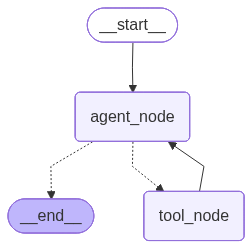

Graph diagram rendered above.


In [ ]:
# Optional: Draw a high-quality PNG diagram
# Requires: pip install grandalf pygraphviz

try:
    from IPython.display import Image, display
    png_bytes = agent_graph.get_graph().draw_mermaid_png()
    display(Image(png_bytes))
    print("Graph diagram rendered above.")
except Exception:
    print("PNG rendering not available. ASCII diagram shown above is sufficient.")

## Step 11 - Draw the Graph Manually (Always Works)

Here is a clear text diagram of exactly what the graph looks like:

In [ ]:
diagram = """
╔══════════════════════════════════════════════════════════════╗
║              LANGGRAPH AGENT - NODE DIAGRAM                  ║
╚══════════════════════════════════════════════════════════════╝

         User sends a message
                  |
                  v
         ┌─────────────────┐
         │   __START__     │   <-- Entry Point
         └────────┬────────┘
                  |
                  v
         ┌─────────────────┐
         │   agent_node    │   <-- LLM (GPT-4o Mini) decides:
         │                 │       "Do I need a tool?"
         └────────┬────────┘
                  |
          [Router: should_use_tool]
                  |
         .--------+--------.
         |                 |
   Tool needed?       No tool needed?
         |                 |
         v                 v
  ┌─────────────┐    ┌──────────┐
  │  tool_node  │    │  __END__ │   <-- Final answer returned
  │             │    └──────────┘
  │ Runs the    │
  │ tool, gets  │
  │ result      │
  └──────┬──────┘
         |  (always loops back)
         v
    [agent_node]  <-- Sees the tool result, decides next step


NODES:
  agent_node  - GPT-4o Mini reads messages, decides action
  tool_node   - Executes the tool requested by the agent

EDGES:
  START        --> agent_node   (always)
  agent_node   --> tool_node    (if tool_calls present)
  agent_node   --> END          (if no tool_calls)
  tool_node    --> agent_node   (always, to process tool result)
"""

print(diagram)


╔══════════════════════════════════════════════════════════════╗
║              LANGGRAPH AGENT - NODE DIAGRAM                  ║
╚══════════════════════════════════════════════════════════════╝

         User sends a message
                  |
                  v
         ┌─────────────────┐
         │   __START__     │   <-- Entry Point
         └────────┬────────┘
                  |
                  v
         ┌─────────────────┐
         │   agent_node    │   <-- LLM (GPT-4o Mini) decides:
         │                 │       "Do I need a tool?"
         └────────┬────────┘
                  |
          [Router: should_use_tool]
                  |
         .--------+--------.
         |                 |
   Tool needed?       No tool needed?
         |                 |
         v                 v
  ┌─────────────┐    ┌──────────┐
  │  tool_node  │    │  __END__ │   <-- Final answer returned
  │             │    └──────────┘
  │ Runs the    │
  │ tool, gets  │
  │ result      │

## Step 12 - Run the Agent

We create a helper function that sends a message to the agent
and prints the final answer.

In [ ]:
def run_agent(user_message: str):
    """
    Send a message to the agent and display the final answer.
    """
    print("=" * 60)
    print(f"User: {user_message}")
    print("=" * 60)

    # Build initial state with the user's message
    initial_state = {
        "messages": [HumanMessage(content=user_message)]
    }

    # Run the graph (it will loop until it reaches END)
    final_state = agent_graph.invoke(initial_state)

    # The last message is the agent's final answer
    final_answer = final_state["messages"][-1].content
    print(f"\nAgent: {final_answer}")
    print()

In [ ]:
# Test 1: Question that requires the calculator tool
run_agent("What is 145 multiplied by 37, and then subtract 500 from the result?")

User: What is 145 multiplied by 37, and then subtract 500 from the result?
[Agent Node] Thinking...
[Agent Node] Decided to use tool(s): ['calculator']
[Tool Node] Executing tool(s)...
[Tool Node] Running 'calculator' with args: {'expression': '145 * 37 - 500'}
[Tool Node] Result: Result: 4865
[Agent Node] Thinking...
[Agent Node] No tool needed. Returning final answer.

Agent: The result of multiplying 145 by 37 and then subtracting 500 is 4865.



In [ ]:
# Test 2: Question that requires the weather tool
run_agent("What is the current weather in Tokyo?")

User: What is the current weather in Tokyo?
[Agent Node] Thinking...
[Agent Node] Decided to use tool(s): ['get_weather']
[Tool Node] Executing tool(s)...
[Tool Node] Running 'get_weather' with args: {'city': 'Tokyo'}
[Tool Node] Result: Weather in Tokyo: Rainy, 18 degrees Celsius
[Agent Node] Thinking...
[Agent Node] No tool needed. Returning final answer.

Agent: The current weather in Tokyo is rainy, with a temperature of 18 degrees Celsius.



In [ ]:
# Test 3: Question that requires the word counter tool
run_agent("How many words are in this sentence: 'The quick brown fox jumps over the lazy dog'")

User: How many words are in this sentence: 'The quick brown fox jumps over the lazy dog'
[Agent Node] Thinking...
[Agent Node] Decided to use tool(s): ['word_counter']
[Tool Node] Executing tool(s)...
[Tool Node] Running 'word_counter' with args: {'text': 'The quick brown fox jumps over the lazy dog'}
[Tool Node] Result: Words: 9, Characters: 43
[Agent Node] Thinking...
[Agent Node] No tool needed. Returning final answer.

Agent: The sentence "The quick brown fox jumps over the lazy dog" contains 9 words.



In [ ]:
# Test 4: Question that does NOT require a tool (answered directly)
run_agent("What is LangGraph used for?")

User: What is LangGraph used for?
[Agent Node] Thinking...
[Agent Node] No tool needed. Returning final answer.

Agent: LangGraph is a tool designed for building and managing language models and their applications. It typically serves several purposes, including:

1. **Model Development**: LangGraph allows developers to create, train, and fine-tune language models for various tasks such as text generation, translation, summarization, and more.

2. **Data Management**: It helps in organizing and managing datasets used for training language models, ensuring that the data is clean, relevant, and properly formatted.

3. **Integration**: LangGraph often provides APIs and interfaces for integrating language models into applications, making it easier for developers to leverage advanced language processing capabilities.

4. **Visualization**: The tool may offer visualization features to help users understand the performance of their models, analyze results, and make informed decisions about mo

## Summary

Here is what we built, step by step:

| Step | What We Did |
|------|-------------|
| 1 | Installed required libraries |
| 2 | Set the OpenAI API key |
| 3 | Imported all modules |
| 4 | Defined three tools: calculator, weather, word counter |
| 5 | Initialized GPT-4o Mini and bound tools to it |
| 6 | Defined AgentState (shared memory for the graph) |
| 7 | Defined two nodes: agent_node and tool_node |
| 8 | Defined a router function to decide the next step |
| 9 | Built and compiled the LangGraph |
| 10 | Drew the graph diagram |
| 11 | Ran the agent on multiple questions |

**Key Concepts:**

- **State** - Shared memory that flows through the graph (holds all messages)
- **Node** - A function that reads state, does work, and returns updated state
- **Edge** - A connection between nodes (can be conditional or fixed)
- **Router** - A function that decides which node to go to next
- **Tool** - A function the agent can call to get information or perform an action

**Key Difference from LangChain:**
LangGraph gives you explicit control over the flow using a graph structure.
You can see exactly which node runs when, making it easier to debug and extend.